In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
diabetes = load_diabetes(as_frame=True)
data = diabetes.frame
X, y = diabetes.data, diabetes.target
df_X, df_y = load_diabetes(as_frame=True, return_X_y=True)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


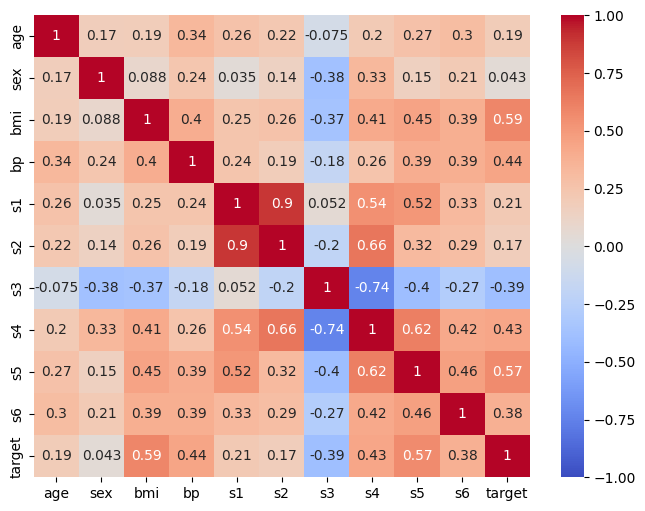

In [ ]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [ ]:
X = df_X[['bmi','bp','s4','s5','s6']]

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X)
df_Y = pd.DataFrame(clusters, columns=['class'])
X_train, X_test, y_train, y_test = train_test_split(X, df_Y, test_size=0.2, random_state=42)

[1 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 1
 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1 0
 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 1
 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 0 0 0 0
 0 0 0 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 0 1
 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0 0
 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 0 0 1 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1
 0 1 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 1 0 1 1 1 1 0
 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0]


In [ ]:
class LoggRegression():
  def predict(self,x,w,b):
    Z = x @ w + b
    return (1 / (1 + np.exp(-Z)))
  def __init__(self,xtrain,ytrain,maxiter = 10000,learningrate = 0.1):
    self.xtrain = np.array(xtrain)
    self.ytrain = np.array(ytrain).reshape(-1, 1)
    n = len(self.xtrain)
    m = len(self.xtrain[0])
    self.weights = np.random.uniform(-1, 1, size=(m,1))
    self.bias = np.random.uniform(-0.5, 0.5)
    oldloss = float('inf')
    iter = 0
    for iter in range(maxiter):
      P = self.predict(self.xtrain,self.weights,self.bias)
      L = -np.mean(self.ytrain*np.log(P) + (1-self.ytrain)*np.log(1 - P))
      gradweight = (self.xtrain.T @ (P - self.ytrain))/n
      gradbias = np.sum(P-self.ytrain)/n
      weightnorm = np.sqrt(np.sum(gradweight**2))
      self.weights = self.weights - learningrate * gradweight
      self.bias = self.bias - learningrate * gradbias
      if (abs(weightnorm) < 0.001 and abs(gradbias) < 0.001) or abs(oldloss - L) < 0.0000001:
        print('Lavaguyn iteracia ::',iter)
        print("Korusti Funkcian :: ", L)
        break
      oldloss = L
    print("Kshirner ::",self.weights)
    print("Shexum ::",self.bias)
    print("Korusti Funkcian :: ", L)
  def metricsgraph(self,xtest,ytest,s=0.5):
    xtest = np.array(xtest)
    ytest = np.array(ytest).reshape(-1, 1)
    P = self.predict(xtest,self.weights,self.bias)
    L = -np.mean(ytest*np.log(P) + (1-ytest)*np.log(1 - P))
    print("Testayin Korusti Funkcian :: ",L)
    accuracy,precision,recall,f1_score,TP,FP,FN,TN = self.metrics(xtest,ytest,P,s)
    print("Accuracy :: ",accuracy*100,"%")
    print("Precision :: ", precision)
    print("Recall :: ", recall)
    print("F1 Score :: ", f1_score)
    cm = np.array([[TP, FP],[FN, TN]])
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Positive", "Negative"])
    ax.set_yticklabels(["Positive", "Negative"])
    for i in range(2):
      for j in range(2):
        ax.text(j, i, str(cm[i, j]),ha='center', va='center', color='black', fontsize=14)
    plt.title("Confusion Matrix")
    plt.colorbar(im)
    plt.show()
    x = np.linspace(0, 1, 100)
    yaccuracy,yprecision,yrecall,yf1_score = [],[],[],[]
    for i in x:
      mt = self.metrics(xtest,ytest,P,i)
      acc,prec,rec,f1 = mt[0],mt[1],mt[2],mt[3]
      yaccuracy.append(acc)
      yprecision.append(prec)
      yrecall.append(rec)
      yf1_score.append(f1)
    yaccuracy = np.array(yaccuracy)
    yprecision = np.array(yprecision)
    yrecall = np.array(yrecall)
    yf1_score = np.array(yf1_score)
    plt.figure(figsize=(10, 6))
    plt.plot(x, yaccuracy, label='Accuracy')
    plt.plot(x, yprecision, label='Precision')
    plt.plot(x, yrecall, label='Recall')
    plt.plot(x, yf1_score, label='F1 Score')
    plt.xticks(np.arange(0, 1.05, 0.05))
    plt.yticks(np.arange(0, 1.05, 0.05))
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

  def inputpredict(self,xarray):
    xarray = np.array(xarray)
    z = xarray @ self.weights + self.bias
    return (1 / (1 + np.exp(-z)))
  def metrics(self,xtest,ytest,P,s):
    P_bin = (P > s).astype(int)
    accuracy = np.mean(P_bin == ytest)
    TP = np.sum((P_bin == 1) & (ytest == 1))
    FP = np.sum((P_bin == 1) & (ytest == 0))
    FN = np.sum((P_bin == 0) & (ytest == 1))
    TN = np.sum((P_bin == 0) & (ytest == 0))
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)
    return accuracy,precision,recall,f1_score,TP,FP,FN,TN





Kshirner :: [[7.75330767]
 [7.60557444]
 [8.36662958]
 [9.9461013 ]
 [7.82745109]]
Shexum :: 0.04123656409255191
Korusti Funkcian ::  0.31263777243542284
Testayin Korusti Funkcian ::  0.33032102552256326
Accuracy ::  100.0 %
Precision ::  0.9999999999743591
Recall ::  0.9999999999743591
F1 Score ::  0.9999999994743591


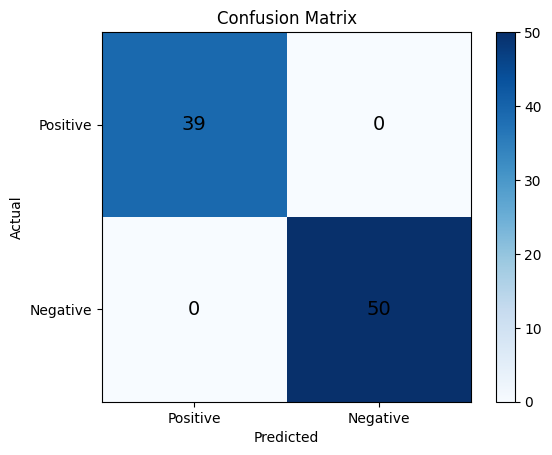

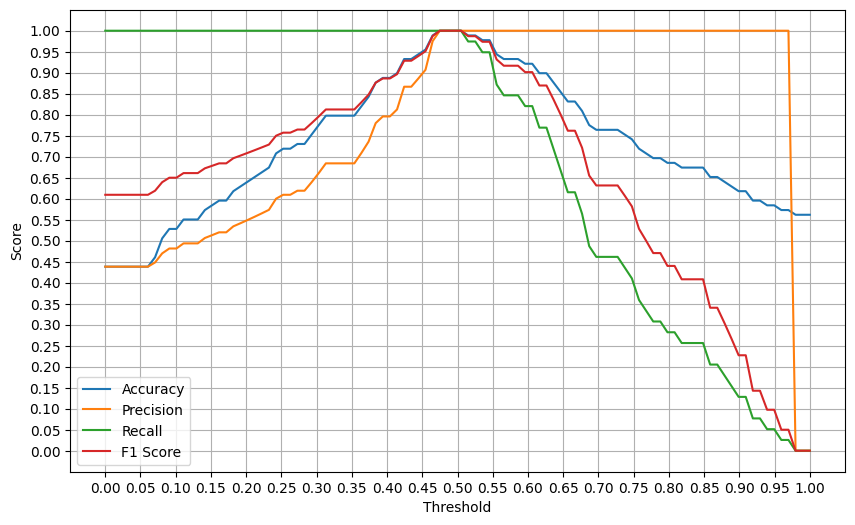

In [ ]:
lgg = LoggRegression(X_train,y_train)
lgg.metricsgraph(X_test,y_test)

<Axes: ylabel='Count'>

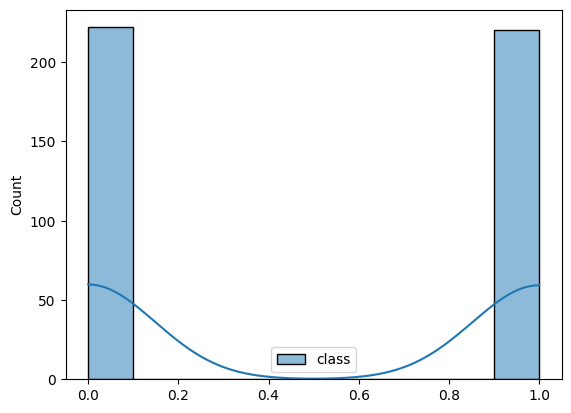

In [ ]:
sns.histplot(data = df_Y, kde = True)